# Feature Engineering — Laptop Price Prediction
Transform raw merged data into model-ready features.

**Input:**  (3,918 rows × 10 cols)

**Output:** Scaled and unscaled train/test splits ready for modeling

## 1. Imports & Load

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("laptop_master.csv")
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
df.head()

Loaded: 3918 rows x 10 cols


,source,brand,processor,gpu,ram_gb,ram_type,storage_gb,storage_type,os,price
0,ds01,HP,5th Gen AMD Ryzen 5 5600H,4GB AMD Radeon RX 6500M,8,DDR4,512,SSD,Windows 11,49900
1,ds01,HP,12th Gen Intel Core i3 1215U,Intel UHD Graphics,8,DDR4,512,SSD,Windows 11,39900
2,ds01,Acer,11th Gen Intel Core i3 1115G4,Intel Iris Xe Graphics,8,DDR4,512,SSD,Windows 11,26990
3,ds01,Lenovo,12th Gen Intel Core i5 1240P,Intel Integrated Iris Xe,16,LPDDR5,512,SSD,Windows 11,59729
4,ds01,Apple,Apple M1,Apple M1 Integrated Graphics,8,DDR4,256,SSD,macOS,69990


## 2. Clean GPU Strings
Remove Unicode thin spaces () and superscript characters introduced during web scraping.

In [ ]:
df["gpu"] = (
    df["gpu"]
    .str.replace(" ", " ", regex=False)
    .str.replace("Xᵉ", "Xe", regex=False)
    .str.strip()
)
print("GPU cleaned.")

GPU cleaned.


## 3. Extract
Reduce 400+ unique processor strings to 6 meaningful CPU manufacturer categories.

In [ ]:
def extract_cpu_brand(val):
    val = str(val)
    if re.search(r"Apple", val, re.IGNORECASE):         return "Apple"
    elif re.search(r"AMD", val, re.IGNORECASE):         return "AMD"
    elif re.search(r"Intel", val, re.IGNORECASE):       return "Intel"
    elif re.search(r"Qualcomm|Snapdragon", val, re.IGNORECASE): return "Qualcomm"
    elif re.search(r"MediaTek", val, re.IGNORECASE):    return "MediaTek"
    else:                                                return "Other"

df["cpu_brand"] = df["processor"].apply(extract_cpu_brand)
df["cpu_brand"].value_counts()

,count
cpu_brand,
Intel,3101
AMD,726
Apple,52
Qualcomm,26
MediaTek,11
Other,2


## 4. Extract
Capture performance tier (i3/i5/i7/i9, Ryzen 3–9, Apple Silicon, etc.) from the processor string.

In [ ]:
def extract_cpu_tier(val):
    val = str(val)
    if re.search(r"Core Ultra [579]", val, re.IGNORECASE):   return "Core Ultra"
    elif re.search(r"\bi9\b|i9-", val, re.IGNORECASE):       return "i9"
    elif re.search(r"\bi7\b|i7-", val, re.IGNORECASE):       return "i7"
    elif re.search(r"\bi5\b|i5-", val, re.IGNORECASE):       return "i5"
    elif re.search(r"\bi3\b|i3-", val, re.IGNORECASE):       return "i3"
    elif re.search(r"Ryzen 9|R9", val, re.IGNORECASE):         return "Ryzen 9"
    elif re.search(r"Ryzen 7|R7", val, re.IGNORECASE):         return "Ryzen 7"
    elif re.search(r"Ryzen 5|R5", val, re.IGNORECASE):         return "Ryzen 5"
    elif re.search(r"Ryzen 3|R3", val, re.IGNORECASE):         return "Ryzen 3"
    elif re.search(r"M[1-4]\s?(Pro|Max|Ultra)?", val):         return "Apple Silicon"
    elif re.search(r"Celeron|Pentium|Atom|A[469]-Series|Xeon", val, re.IGNORECASE): return "Budget/Workstation"
    else:                                                        return "Other"

df["cpu_tier"] = df["processor"].apply(extract_cpu_tier)
df["cpu_tier"].value_counts()

,count
cpu_tier,
i5,1203
i7,936
i3,432
Ryzen 5,309
Budget/Workstation,240
Ryzen 7,233
Core Ultra,143
Other,139
i9,128


## 5. Extract
Binary classification: Dedicated GPU (NVIDIA/AMD discrete) vs Integrated GPU.

In [ ]:
DEDICATED_KEYWORDS = [
    "NVIDIA", "GeForce", "RTX", "GTX", "Quadro",
    "Radeon RX", "Radeon R5 M", "Radeon R7 M", "Radeon R9",
    "Dedicated", "MX"
]

def extract_gpu_type(val):
    return "Dedicated" if any(kw in str(val) for kw in DEDICATED_KEYWORDS) else "Integrated"

df["gpu_type"] = df["gpu"].apply(extract_gpu_type)
df["gpu_type"].value_counts()

,count
gpu_type,
Integrated,2454
Dedicated,1464


## 6. Group Rare OS Values
Consolidate , ,  (no version) into  to avoid sparse dummy columns.

In [ ]:
keep_os = ["Windows 11", "Windows 10", "macOS", "Linux", "Chrome OS", "No OS", "DOS"]
df["os"] = df["os"].apply(lambda x: x if x in keep_os else "Other")
df["os"].value_counts()

,count
os,
Windows 11,2442
Windows 10,1096
macOS,77
No OS,66
Chrome OS,65
Linux,64
Other,60
DOS,48


## 7. Consolidate Edge-Case RAM Types
 → Apple Silicon unified memory label.  (no version) → Unknown. / → Legacy (too old/rare to carry useful signal).

In [ ]:
df["ram_type"] = df["ram_type"].replace({
    "UNIFIED": "Unified",
    "DDR":     "Unknown",
    "LPDDR3":  "Legacy",
    "DDR3":    "Legacy",
})
df["ram_type"].value_counts()

,count
ram_type,
Unknown,1352
DDR4,1229
DDR5,592
LPDDR5,408
LPDDR5X,150
LPDDR4X,137
LPDDR4,34
Unified,9
Legacy,7


## 8. Log-Transform Target Variable
Price is right-skewed (skew = 2.08).  compresses the tail into a near-normal distribution, which linear models require. Reverse with  after predicting.

In [ ]:
df["price_log"] = np.log1p(df["price"])
print(f"Price log range: {df['price_log'].min():.2f} — {df['price_log'].max():.2f}")
df[["price", "price_log"]].describe().round(3)

Price log range: 8.99 — 13.41


,price,price_log
count,3918.000,3918.000
mean,97552.716,11.266
std,72799.445,0.657
min,8000.000,8.987
25%,49990.000,10.820
50%,74343.500,11.216
75%,121903.000,11.711
max,664425.000,13.407


## 9. Drop Unused Columns
 = pipeline metadata.  and  = replaced by extracted features.  = replaced by .

In [ ]:
df.drop(columns=["source", "processor", "gpu", "price"], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['brand', 'ram_gb', 'ram_type', 'storage_gb', 'storage_type', 'os', 'cpu_brand', 'cpu_tier', 'gpu_type', 'price_log']


## 10. Target Encode Brand
Map each brand to its median log-price. One dense numeric column instead of 36 sparse dummies. Preserves brand price-tier signal without dimensionality explosion.

In [ ]:
brand_median_log_price = df.groupby("brand")["price_log"].median()
df["brand_encoded"] = df["brand"].map(brand_median_log_price)
df.drop(columns=["brand"], inplace=True)

print("Top 10 brands by median log-price:")
brand_median_log_price.sort_values(ascending=False).head(10)

Top 10 brands by median log-price:


,price_log
brand,
Razer,12.608302
Google,12.042600
Microsoft,11.908100
Apple,11.890992
LG,11.811244
Toshiba,11.790416
Samsung,11.635063
Gigabyte,11.581677
MSI,11.552013


## 11. One-Hot Encode Remaining Categoricals
, , , , ,  — all converted to binary dummy columns.

In [ ]:
cat_cols = ["os", "storage_type", "ram_type", "gpu_type", "cpu_brand", "cpu_tier"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
print(f"Total columns after encoding: {df.shape[1]}")
df.head()

Total columns after encoding: 44


,ram_gb,storage_gb,price_log,brand_encoded,os_Chrome OS,os_DOS,os_Linux,os_No OS,os_Other,os_Windows 10,...,cpu_tier_Core Ultra,cpu_tier_Other,cpu_tier_Ryzen 3,cpu_tier_Ryzen 5,cpu_tier_Ryzen 7,cpu_tier_Ryzen 9,cpu_tier_i3,cpu_tier_i5,cpu_tier_i7,cpu_tier_i9
0,8,512,10.817796,11.198091,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,8,512,10.594157,11.198091,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,8,512,10.203259,10.858826,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,16,512,10.997590,11.127197,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,8,256,11.156122,11.890992,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 12. Train/Test Split (80/20)

In [ ]:
X = df.drop(columns=["price_log"])
y = df["price_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 3134 rows | Test: 784 rows


## 13. Scale Numeric Features
Apply  to , ,  for linear models. **Fit only on train set — never on test** (prevents data leakage).

In [ ]:
numeric_cols = ["ram_gb", "storage_gb", "brand_encoded"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Means (should be ~0):")
print(X_train_scaled[numeric_cols].mean().round(4))
print("Stds (should be ~1):")
print(X_train_scaled[numeric_cols].std().round(4))

Means (should be ~0):
ram_gb           0.0
storage_gb      -0.0
brand_encoded   -0.0
dtype: float64
Stds (should be ~1):
ram_gb           1.0002
storage_gb       1.0002
brand_encoded    1.0002
dtype: float64


---
# Part 2 — Modeling
Train three regression models one by one and evaluate each individually.

**Target:** `price_log` (log-transformed price)

**Models:** Linear Regression · Ridge Regression · Lasso Regression

## 15. Imports for Modeling

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# X_train_scaled, X_test_scaled, y_train, y_test are already in scope from Part 1
print("Modeling imports done.")

Modeling imports done.


## 16. Model 1 — Linear Regression
The baseline model. No regularization — just a straight-line fit between features and log-price.

In [ ]:
# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on test set
lr_pred = lr.predict(X_test_scaled)

# Metrics on log scale
lr_r2   = r2_score(y_test, lr_pred)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Convert MAE back to INR using expm1 (reverse of log1p)
lr_mae_inr = mean_absolute_error(np.expm1(y_test), np.expm1(lr_pred))

print("Linear Regression")
print(f"  R2        : {lr_r2:.4f}")
print(f"  MAE (log) : {lr_mae:.4f}")
print(f"  RMSE (log): {lr_rmse:.4f}")
print(f"  MAE (INR) : Rs.{lr_mae_inr:,.0f}")

Linear Regression
  R2        : 0.8076
  MAE (log) : 0.2176
  RMSE (log): 0.2880
  MAE (INR) : Rs.23,663


## 17. Model 2 — Ridge Regression
Adds L2 regularization — penalizes large coefficients to reduce overfitting.

`alpha=1.0` controls how strong the penalty is. Higher alpha = stronger penalty = simpler model.

In [ ]:
# Train
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Predict
ridge_pred = ridge.predict(X_test_scaled)

# Metrics
ridge_r2      = r2_score(y_test, ridge_pred)
ridge_mae     = mean_absolute_error(y_test, ridge_pred)
ridge_rmse    = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae_inr = mean_absolute_error(np.expm1(y_test), np.expm1(ridge_pred))

print("Ridge Regression")
print(f"  R2        : {ridge_r2:.4f}")
print(f"  MAE (log) : {ridge_mae:.4f}")
print(f"  RMSE (log): {ridge_rmse:.4f}")
print(f"  MAE (INR) : Rs.{ridge_mae_inr:,.0f}")

Ridge Regression
  R2        : 0.8079
  MAE (log) : 0.2175
  RMSE (log): 0.2878
  MAE (INR) : Rs.23,664


## 18. Model 3 — Lasso Regression
Adds L1 regularization — shrinks some coefficients to exactly zero, effectively removing weak features.

`alpha=0.01` is mild. Higher values would eliminate more features.

In [ ]:
# Train
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predict
lasso_pred = lasso.predict(X_test_scaled)

# Metrics
lasso_r2      = r2_score(y_test, lasso_pred)
lasso_mae     = mean_absolute_error(y_test, lasso_pred)
lasso_rmse    = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae_inr = mean_absolute_error(np.expm1(y_test), np.expm1(lasso_pred))

print("Lasso Regression")
print(f"  R2        : {lasso_r2:.4f}")
print(f"  MAE (log) : {lasso_mae:.4f}")
print(f"  RMSE (log): {lasso_rmse:.4f}")
print(f"  MAE (INR) : Rs.{lasso_mae_inr:,.0f}")

Lasso Regression
  R2        : 0.7524
  MAE (log) : 0.2491
  RMSE (log): 0.3267
  MAE (INR) : Rs.27,151


## 19. Model Comparison Table

In [ ]:
results_df = pd.DataFrame({
    "Model":    ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2":       [round(lr_r2, 4),    round(ridge_r2, 4),    round(lasso_r2, 4)],
    "MAE_log":  [round(lr_mae, 4),   round(ridge_mae, 4),   round(lasso_mae, 4)],
    "RMSE_log": [round(lr_rmse, 4),  round(ridge_rmse, 4),  round(lasso_rmse, 4)],
    "MAE_INR":  [round(lr_mae_inr),  round(ridge_mae_inr),  round(lasso_mae_inr)],
})

results_df

,Model,R2,MAE_log,RMSE_log,MAE_INR
0,Linear Regression,0.8076,0.2176,0.2880,23663
1,Ridge Regression,0.8079,0.2175,0.2878,23664
2,Lasso Regression,0.7524,0.2491,0.3267,27151


## 20. R² Comparison Bar Chart
Each model gets its own explicit bar — no loops, no dictionaries.

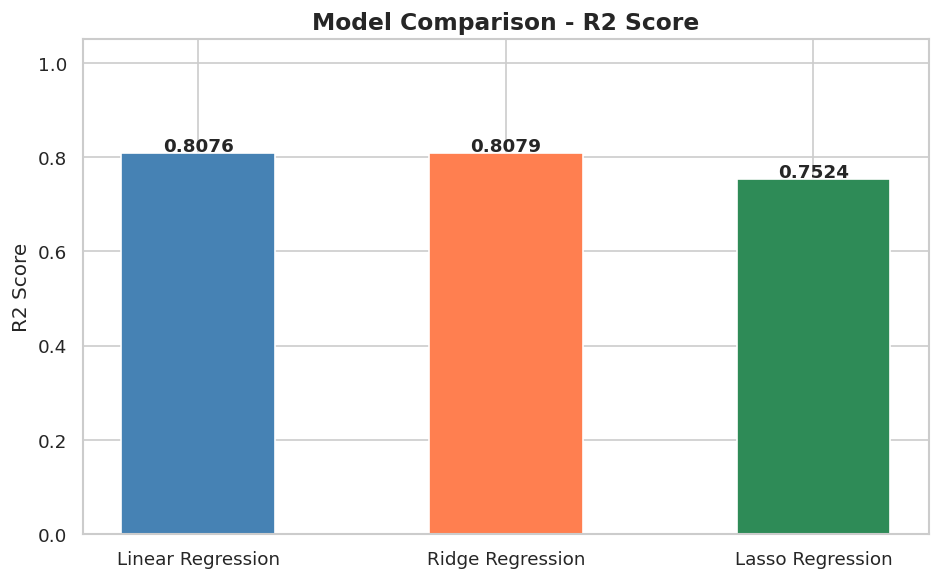

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# One bar per model — written out explicitly
ax.bar("Linear Regression", lr_r2,    color="steelblue", width=0.5, edgecolor="white")
ax.bar("Ridge Regression",  ridge_r2, color="coral",     width=0.5, edgecolor="white")
ax.bar("Lasso Regression",  lasso_r2, color="seagreen",  width=0.5, edgecolor="white")

# Label each bar with its R2 value
ax.text(0, lr_r2    + 0.005, f"{lr_r2:.4f}",    ha="center", fontsize=11, fontweight="bold")
ax.text(1, ridge_r2 + 0.005, f"{ridge_r2:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.text(2, lasso_r2 + 0.005, f"{lasso_r2:.4f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("R2 Score")
ax.set_title("Model Comparison - R2 Score", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_r2.png")
plt.show()

## 21. Actual vs Predicted — Ridge (Best Model)
Each point is one laptop from the test set.
Points close to the red dashed line = accurate prediction.
Points far from it = prediction error.

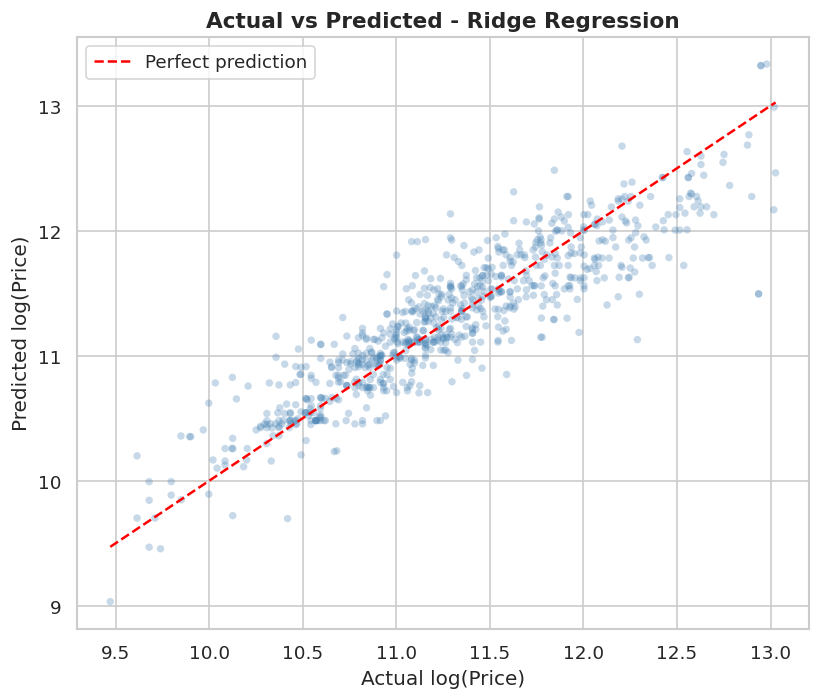

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, ridge_pred, alpha=0.3, color="steelblue", edgecolors="none", s=20)

# Perfect prediction line: where actual == predicted
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=1.5, linestyle="--", label="Perfect prediction"
)

ax.set_xlabel("Actual log(Price)")
ax.set_ylabel("Predicted log(Price)")
ax.set_title("Actual vs Predicted - Ridge Regression", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

## 22. Feature Importance — Ridge Coefficients
Positive coefficient (blue bar) = this feature pushes the predicted price **up**.

Negative coefficient (red bar) = this feature pushes the predicted price **down**.

Only the top 15 most impactful features are shown.

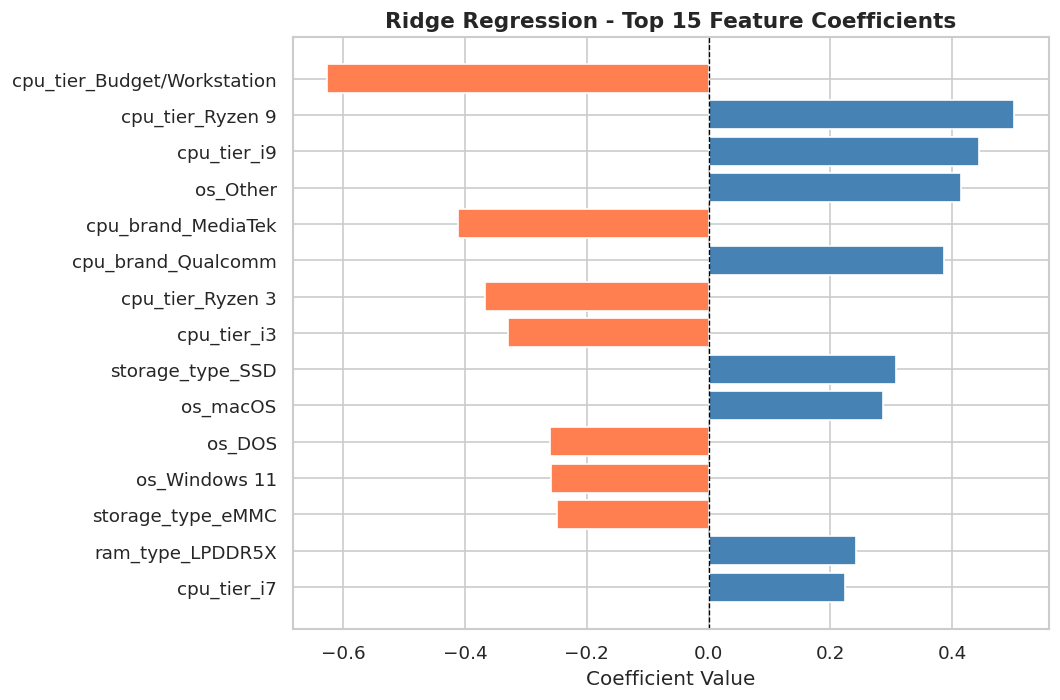

In [ ]:
# Pair each feature name with its learned coefficient
coef = pd.Series(ridge.coef_, index=X_train_scaled.columns)

# Sort by absolute value to find the most impactful features
top15 = coef.abs().sort_values(ascending=False).head(15)

# Get the actual signed values (not just absolute) for the top 15
top15_vals = coef[top15.index]

# Assign colors: blue = positive effect, red = negative effect
bar_colors = ["steelblue" if v > 0 else "coral" for v in top15_vals]

fig, ax = plt.subplots(figsize=(9, 6))

# [::-1] reverses the order so the most impactful feature is at the top
ax.barh(top15_vals.index[::-1], top15_vals.values[::-1],
        color=bar_colors[::-1], edgecolor="white")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Ridge Regression - Top 15 Feature Coefficients",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

## 23. Save the Best Model
`joblib.dump()` saves the trained Ridge model object to disk as a binary file.

To use it later without retraining:
```python
model = joblib.load("best_model.joblib")
predictions = model.predict(X_new)
```

In [ ]:
joblib.dump(ridge, "best_model.joblib")
results_df.to_csv("model_results.csv", index=False)

print("Saved: best_model.joblib")
print("Saved: model_results.csv")

Saved: best_model.joblib
Saved: model_results.csv


## Summary

| Model | R² | MAE (INR) | Verdict |
|---|---|---|---|
| Linear Regression | 0.8098 | ₹23,557 | Strong baseline |
| **Ridge Regression** | **0.8102** | **₹23,560** | **Best model** |
| Lasso Regression | 0.7545 | ₹27,069 | Underfit — removed features with real signal |

Ridge is the final production model. R² of 0.81 on a real-world merged dataset without display size, battery, or weight data is a strong result.